# Predictive Modeling for Chronic Kidney Disease

This notebook develops machine learning models to predict Chronic Kidney Disease (CKD) using clinical indicators.

The objectives are to:

- Train multiple machine learning models
- Evaluate predictive performance
- Compare model accuracy and diagnostic metrics
- Identify the most effective model for CKD prediction

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set_style("whitegrid")

print("Libraries loaded.")

Libraries loaded.


In [2]:
FILE_PATH = "/content/ckd_cleaned_final.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset loaded.")
print("Shape:", df.shape)

df.head()

Dataset loaded.
Shape: (200, 27)


,bp_diastolic,bp limit,sg,al,class,rbc,su,pc,pcc,ba,...,rbcc,wbcc,htn,dm,cad,appet,pe,ane,grf,age
0,0.0,0.0,1.020,1.0,1,0.0,0.0,0.0,0.0,0.0,...,4.755,8550.0,0.0,0.0,0.0,0.0,0.0,0.0,227.9440,12.0
1,0.0,0.0,1.010,0.0,1,0.0,0.0,0.0,0.0,0.0,...,4.755,13310.0,0.0,0.0,0.0,0.0,0.0,0.0,227.9440,12.0
2,0.0,0.0,1.010,4.0,1,1.0,0.0,1.0,0.0,1.0,...,4.755,15690.0,0.0,0.0,0.0,1.0,0.0,0.0,139.8635,12.0
3,1.0,1.0,1.010,3.0,1,0.0,0.0,0.0,0.0,0.0,...,4.755,8550.0,0.0,0.0,0.0,0.0,0.0,0.0,139.8635,12.0
4,0.0,0.0,1.016,0.0,1,0.0,0.0,0.0,0.0,0.0,...,5.345,8550.0,0.0,1.0,0.0,1.0,1.0,0.0,139.8635,16.0


In [5]:
df = df.rename(columns={"class": "ckd"})

## Define Features and Target Variable

In [6]:
X = df.drop(columns=["ckd"])
y = df["ckd"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (200, 26)
Target shape: (200,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


## Logistic Regression Baseline

In [9]:
missing_summary = X.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

print("Columns with missing values:")
print(missing_summary)

print("\nTotal missing values in X:", X.isna().sum().sum())

Columns with missing values:
grf    1
dtype: int64

Total missing values in X: 1


In [12]:
log_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=500, class_weight="balanced", random_state=42))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Results")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

Logistic Regression Results
Accuracy: 0.975
Precision: 1.0
Recall: 0.9615
F1 Score: 0.9804
ROC-AUC: 1.0


In [13]:
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall:", round(recall_score(y_test, rf_pred), 4))
print("F1 Score:", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))

Random Forest Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


In [14]:
gb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting Results")
print("Accuracy:", round(accuracy_score(y_test, gb_pred), 4))
print("Precision:", round(precision_score(y_test, gb_pred), 4))
print("Recall:", round(recall_score(y_test, gb_pred), 4))
print("F1 Score:", round(f1_score(y_test, gb_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, gb_prob), 4))

Gradient Boosting Results
Accuracy: 0.975
Precision: 1.0
Recall: 0.9615
F1 Score: 0.9804
ROC-AUC: 1.0


In [15]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.975,1.0,0.9615,0.9804,1.0
1,Random Forest,1.000,1.0,1.0000,1.0000,1.0
2,Gradient Boosting,0.975,1.0,0.9615,0.9804,1.0


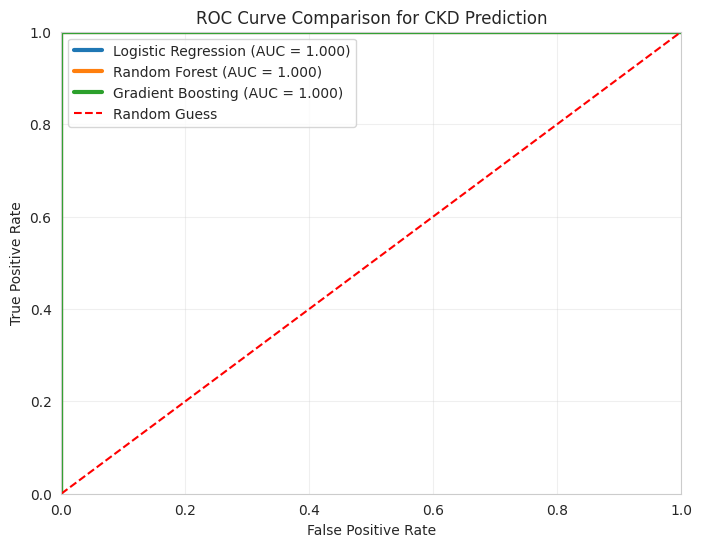

In [17]:
plt.figure(figsize=(8,6))

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

plt.plot(fpr_log, tpr_log, linewidth=3, label="Logistic Regression (AUC = {:.3f})".format(roc_auc_score(y_test, y_prob)))
plt.plot(fpr_rf, tpr_rf, linewidth=3, label="Random Forest (AUC = {:.3f})".format(roc_auc_score(y_test, rf_prob)))
plt.plot(fpr_gb, tpr_gb, linewidth=3, label="Gradient Boosting (AUC = {:.3f})".format(roc_auc_score(y_test, gb_prob)))

plt.plot([0,1], [0,1], linestyle="--", color="red", label="Random Guess")

plt.xlim(0,1)
plt.ylim(0,1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for CKD Prediction")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

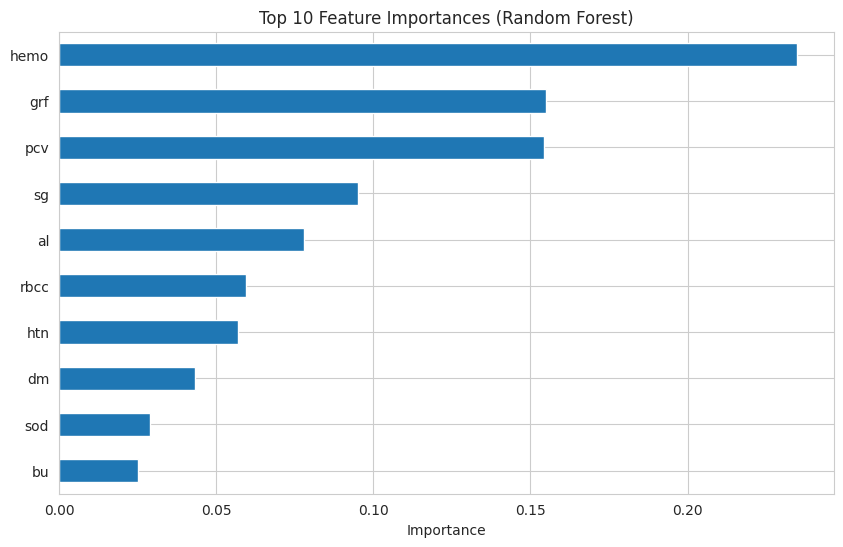

In [18]:
rf_classifier = rf_model.named_steps["classifier"]

feature_importance = pd.Series(
    rf_classifier.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

feature_importance.head(10).plot(kind="barh")

plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")

plt.show()

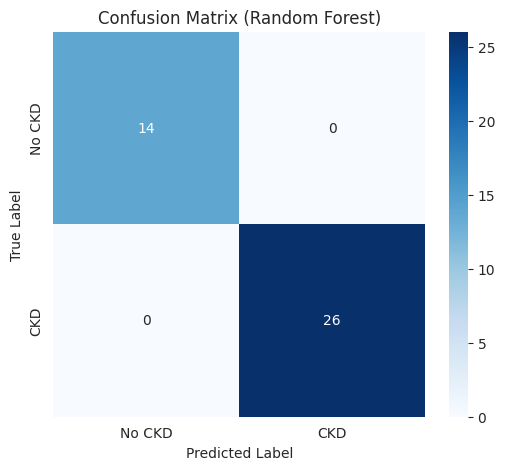

In [19]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No CKD","CKD"],
    yticklabels=["No CKD","CKD"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Random Forest)")

plt.show()

## Model Interpretation

Feature importance analysis from the Random Forest model indicates that hemoglobin, glomerular filtration rate (GFR), packed cell volume (PCV), and urine specific gravity are the most influential predictors of chronic kidney disease.

These findings align with established clinical knowledge, as reduced hemoglobin levels and impaired kidney filtration markers are strongly associated with CKD progression.

The agreement between exploratory data analysis and model feature importance suggests that the model is learning meaningful physiological relationships rather than spurious correlations.

In [20]:
import joblib

joblib.dump(rf_model, "ckd_random_forest_model.pkl")

print("Model saved as ckd_random_forest_model.pkl")

Model saved as ckd_random_forest_model.pkl


## Model Explainability with SHAP

To improve interpretability, we use SHAP (SHapley Additive exPlanations) to explain the Random Forest model.

SHAP helps answer two important questions:

- Which features are most important overall?
- How do individual features push a prediction toward CKD or non-CKD?

This is especially valuable in healthcare machine learning, where model transparency matters alongside predictive performance.

In [26]:
!pip -q install shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)
print("NumPy version:", np.__version__)

SHAP version: 0.51.0
NumPy version: 2.0.2


In [27]:
rf_imputer = rf_model.named_steps["imputer"]
rf_classifier = rf_model.named_steps["classifier"]

print("Imputer type:", type(rf_imputer))
print("Classifier type:", type(rf_classifier))
print("Number of input features:", len(X.columns))
print("First 10 feature names:", X.columns.tolist()[:10])

Imputer type: <class 'sklearn.impute._base.SimpleImputer'>
Classifier type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Number of input features: 26
First 10 feature names: ['bp_diastolic', 'bp limit', 'sg', 'al', 'rbc', 'su', 'pc', 'pcc', 'ba', 'bgr']


In [28]:
X_train_imputed = pd.DataFrame(
    rf_imputer.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    rf_imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("X_train_imputed shape:", X_train_imputed.shape)
print("X_test_imputed shape:", X_test_imputed.shape)
print("\nAny NaNs left in training set?", X_train_imputed.isna().sum().sum())
print("Any NaNs left in test set?", X_test_imputed.isna().sum().sum())
print("\nDtypes summary:")
print(X_test_imputed.dtypes.value_counts())

X_train_imputed shape: (160, 26)
X_test_imputed shape: (40, 26)

Any NaNs left in training set? 0
Any NaNs left in test set? 0

Dtypes summary:
float64    26
Name: count, dtype: int64


In [29]:
explainer = shap.TreeExplainer(rf_classifier)
raw_shap_values = explainer.shap_values(X_test_imputed)

print("Type of raw_shap_values:", type(raw_shap_values))

if isinstance(raw_shap_values, list):
    print("raw_shap_values is a list")
    print("Length:", len(raw_shap_values))
    for i, sv in enumerate(raw_shap_values):
        print(f"Class {i} SHAP shape:", np.array(sv).shape)
else:
    print("raw_shap_values shape:", np.array(raw_shap_values).shape)

print("\nType of expected_value:", type(explainer.expected_value))
print("expected_value:", explainer.expected_value)
print("\nX_test_imputed shape:", X_test_imputed.shape)

Type of raw_shap_values: <class 'numpy.ndarray'>
raw_shap_values shape: (40, 26, 2)

Type of expected_value: <class 'numpy.ndarray'>
expected_value: [0.50426571 0.49573429]

X_test_imputed shape: (40, 26)


In [30]:
shap_values_ckd = raw_shap_values[:, :, 1]

print("SHAP matrix for CKD class shape:", shap_values_ckd.shape)
print("Expected X_test_imputed shape:", X_test_imputed.shape)

print("\nFirst 5 feature names:")
print(X_test_imputed.columns.tolist()[:5])

print("\nFirst row, first 5 SHAP values:")
print(shap_values_ckd[0, :5])

SHAP matrix for CKD class shape: (40, 26)
Expected X_test_imputed shape: (40, 26)

First 5 feature names:
['bp_diastolic', 'bp limit', 'sg', 'al', 'rbc']

First row, first 5 SHAP values:
[ 0.00040663 -0.00424524 -0.04625774 -0.04297017 -0.00032206]


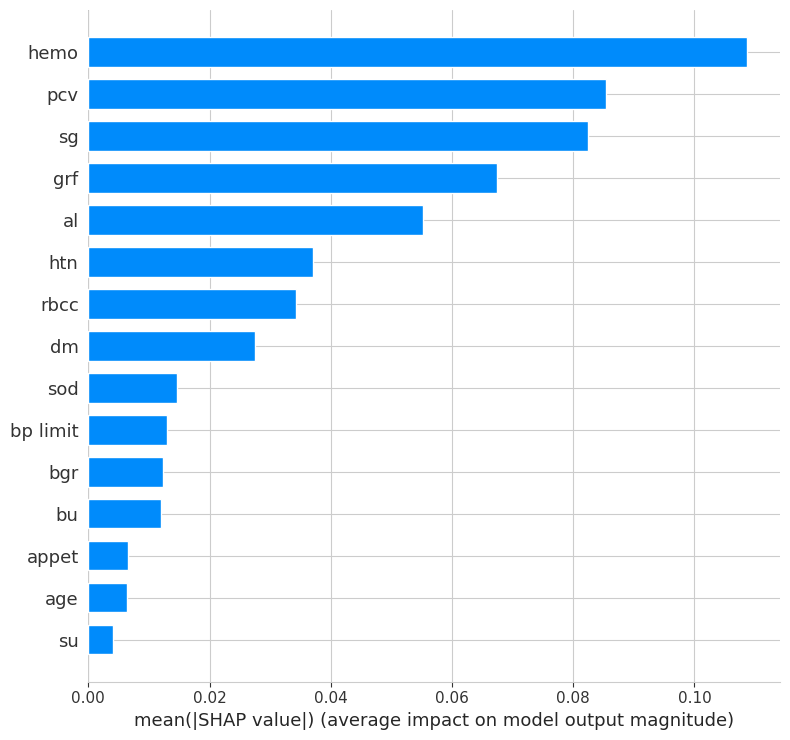

In [31]:
shap.summary_plot(
    shap_values_ckd,
    X_test_imputed,
    plot_type="bar",
    max_display=15
)

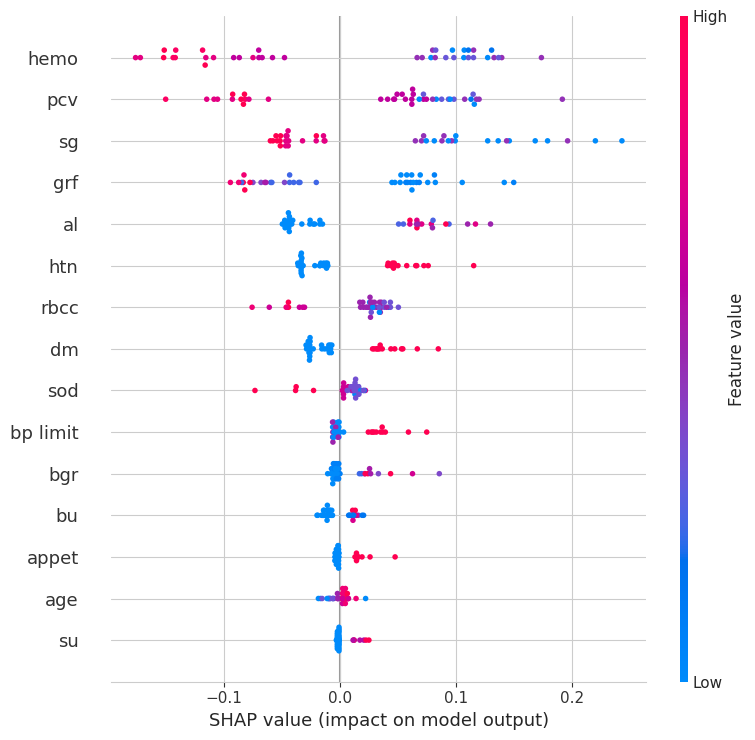

In [32]:
shap.summary_plot(
    shap_values_ckd,
    X_test_imputed,
    max_display=15
)

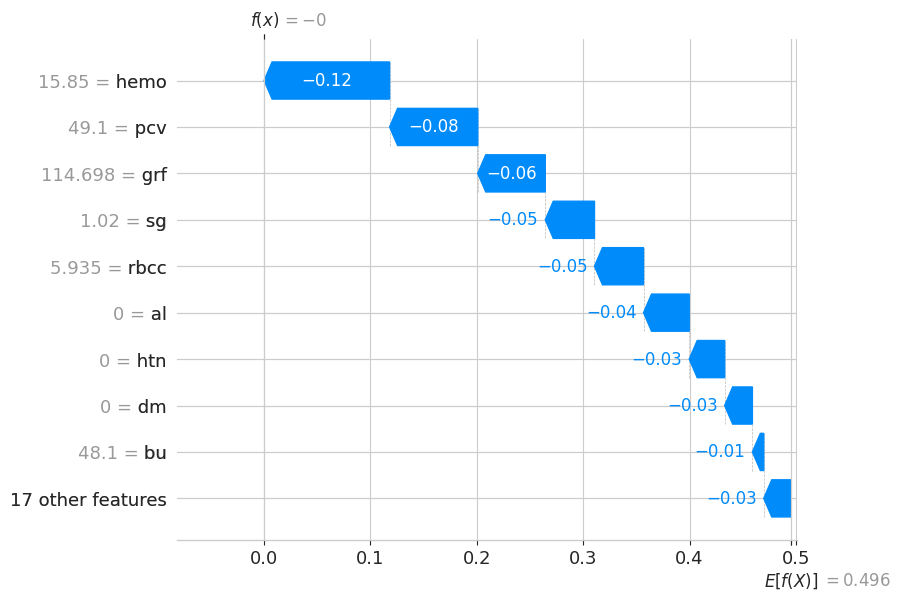

In [33]:
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_ckd[sample_index],
        base_values=explainer.expected_value[1],
        data=X_test_imputed.iloc[sample_index],
        feature_names=X_test_imputed.columns.tolist()
    )
)

## Model Explainability

SHAP analysis confirms that the Random Forest model relies primarily on clinically meaningful features such as hemoglobin, packed cell volume, urine specific gravity, and glomerular filtration rate.

Low hemoglobin and low packed cell volume strongly increase the likelihood of a CKD prediction, which is consistent with the anemia commonly observed in chronic kidney disease patients.

The agreement between exploratory analysis, feature importance rankings, and SHAP explanations suggests that the model is capturing medically relevant relationships rather than spurious correlations.